# U.S. County Health Outcomes: Drivers, Access, and Telehealth Market Strategy

**Author:** Divya Yadav &nbsp;|&nbsp; [LinkedIn](https://linkedin.com/in/divya-yadav-ncsu) &nbsp;|&nbsp; [GitHub](https://github.com/diviyadav03-droid)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/diviyadav03-droid/healthcare-risk-modeling/blob/main/notebooks/county_health_outcomes_analysis.ipynb)

## Overview

This project analyzes county-level health outcomes across the United States to identify the behavioral, socioeconomic,
and healthcare-access factors most strongly associated with life expectancy and physical/mental health burden. It was
developed as a market-entry feasibility study for **GetBetterHealth.com**, a telehealth provider evaluating where to
prioritize geographic expansion.

## Business Questions

1. Which factors are most strongly associated with poor health outcomes at the county level?
2. Does healthcare access (primary care physician supply) matter independently of income?
3. Can counties be segmented into distinct health-risk archetypes to prioritize a market-entry strategy?
4. Which counties represent the highest-priority opportunity for a telehealth expansion strategy?

**Methods:** exploratory data analysis, correlation analysis, linear regression, random forest regression with
cross-validation and feature importance, income-controlled comparative analysis, K-means clustering, and a
rule-based opportunity screen for telehealth market prioritization.

> **Note:** All relationships reported here are statistical associations derived from observational, cross-sectional
> data. They do not establish causation. See **Limitations** for a full discussion.

## Data Source and Dataset

This analysis uses the [County Health Rankings & Roadmaps, 2024](https://www.countyhealthrankings.org/health-data)
dataset, a program of the University of Wisconsin Population Health Institute in collaboration with the Robert
Wood Johnson Foundation. The dataset covers 3,143 U.S. counties across 88 variables spanning health outcomes,
health behaviors, clinical care, social and economic factors, and the physical environment.

**This repository does not include the raw data file.** To reproduce the analysis, download the 2024 dataset from
the official source above and save it as `data/analytic_data2024_case.csv` in this repository. Redistribution
terms for the raw file have not been independently verified, so it is left to users to obtain it directly from
County Health Rankings & Roadmaps.

### Running This Notebook

- This notebook lives in `notebooks/` and expects the dataset at `../data/analytic_data2024_case.csv` relative to
  that location.
- Dependencies: `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn` (see `requirements.txt`).
- Generated charts are written to `../visualizations/`.
- Run all cells in order (**Runtime → Run all** in Colab, or **Run All** in Jupyter).

## 1. Environment Setup

In [1]:
# Uncomment if running outside Colab and packages are not yet installed
# !pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

RANDOM_STATE = 42

# All generated charts are written here (repository-relative, works when the
# notebook is run from its home in notebooks/)
VIS_DIR = Path("../visualizations")
VIS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Data Loading

The source file has a two-row header: the first row contains human-readable labels, and the second contains the
short variable codes (e.g. `v147_rawvalue`) used programmatically throughout this notebook. Rows below that are
one record per county, state, or the national total.

In [2]:
# Optional: if running in Google Colab and the dataset is not available via a
# mounted/cloned repository, uncomment the two lines below to upload it manually.
# from google.colab import files
# uploaded = files.upload()

DATA_PATH = Path("../data/analytic_data2024_case.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Please download the 2024 County Health Rankings dataset "
        "and place 'analytic_data2024_case.csv' in the repository's data/ folder."
    )

df_raw = pd.read_csv(DATA_PATH, skiprows=1)
print(f"Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns")
df_raw.head(3)

Loaded 3,195 rows and 88 columns


,statecode,countycode,fipscode,state,county,year,county_clustered,v001_rawvalue,v001_flag,v002_rawvalue,...,v178_rawvalue,v156_rawvalue,v153_rawvalue,v154_rawvalue,v166_rawvalue,v051_rawvalue,v052_rawvalue,v053_rawvalue,v057_rawvalue,v058_rawvalue
0,0,0,0,US,United States,2024,NaN,7971.509789,0,0.142,...,0.652,107.616657,0.648164,0.144915,0.883467,333287557,0.217382,0.173408,0.504081,0.200031
1,1,0,1000,AL,Alabama,2024,NaN,11415.734830,0,0.178,...,NaN,67.328709,0.697200,0.122664,0.837864,5074296,0.219057,0.180268,0.513753,0.422628
2,1,1,1001,AL,Autauga County,2024,1.0,9407.948438,0,0.173,...,0.688,46.473848,0.754528,0.112794,0.890667,59759,0.232283,0.164109,0.512960,0.406768


In [3]:
# Restrict to county-level records (state and national rows carry countycode == 0)
counties = df_raw[df_raw["countycode"] != 0].copy()

print(f"County-level records: {len(counties):,}")
print(f"States represented:   {counties['state'].nunique()}")

County-level records: 3,143
States represented:   51


### Outcome variables

Three outcome variables anchor the analysis:

| Code | Outcome | Description |
|---|---|---|
| `v147_rawvalue` | Life Expectancy (years) | Average years a resident can expect to live |
| `v036_rawvalue` | Poor Physical Health Days | Avg. days/month adults report poor physical health |
| `v042_rawvalue` | Poor Mental Health Days | Avg. days/month adults report poor mental health |

In [4]:
OUTCOMES = ["v147_rawvalue", "v036_rawvalue", "v042_rawvalue"]
OUTCOME_NAMES = {
    "v147_rawvalue": "Life Expectancy (yrs)",
    "v036_rawvalue": "Poor Physical Health Days/Mo",
    "v042_rawvalue": "Poor Mental Health Days/Mo",
}

counties[OUTCOMES].describe().T

,count,mean,std,min,25%,50%,75%,max
v147_rawvalue,3070.0,75.754919,3.433612,55.918958,73.570987,75.844154,77.993948,98.902938
v036_rawvalue,3143.0,3.896117,0.647391,2.261790,3.397609,3.874097,4.338087,6.836834
v042_rawvalue,3143.0,5.217661,0.613475,3.185544,4.818337,5.235907,5.631876,7.388805


## 3. Data Preparation

Of the 88 available variables, a focused subset spanning four categories — health behaviors, socioeconomics,
healthcare access, and environment/demographics — is used as predictors throughout the analysis.

In [5]:
PREDICTOR_VARS = {
    # Health behaviors
    "v009_rawvalue": "Adult Smoking %",
    "v011_rawvalue": "Adult Obesity %",
    "v070_rawvalue": "Physical Inactivity %",
    "v049_rawvalue": "Excessive Drinking %",
    "v143_rawvalue": "Insufficient Sleep %",
    # Socioeconomic factors
    "v063_rawvalue": "Median Household Income",
    "v024_rawvalue": "Children in Poverty %",
    "v023_rawvalue": "Unemployment %",
    "v044_rawvalue": "Income Inequality (ratio)",
    "v139_rawvalue": "Food Insecurity %",
    "v168_rawvalue": "HS Completion %",
    "v069_rawvalue": "Some College %",
    "v082_rawvalue": "Single-Parent HH %",
    # Healthcare access
    "v004_rawvalue": "PCP per 100k",
    "v062_rawvalue": "MH Providers per 100k",
    "v004_other_data_1": "Pop-to-PCP Ratio",
    "v085_rawvalue": "Uninsured %",
    # Environment & demographics
    "v133_rawvalue": "Food Environment Index",
    "v058_rawvalue": "Rural %",
    "v060_rawvalue": "Diabetes Prevalence %",
    "v166_rawvalue": "Broadband Access %",
}

ALL_VARS = OUTCOMES + list(PREDICTOR_VARS.keys())

# Coerce to numeric; non-numeric placeholders (e.g. "--") become NaN
for col in ALL_VARS:
    counties[col] = pd.to_numeric(counties[col], errors="coerce")

In [6]:
missing = counties[ALL_VARS].isnull().sum()
missing_pct = (missing / len(counties) * 100).round(1)
missing_report = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
missing_report

,missing_count,missing_pct
v062_rawvalue,185,5.9
v004_rawvalue,157,5.0
v004_other_data_1,157,5.0
v147_rawvalue,73,2.3
v133_rawvalue,35,1.1
v044_rawvalue,15,0.5
v143_rawvalue,3,0.1
v063_rawvalue,1,0.0
v024_rawvalue,1,0.0
v023_rawvalue,1,0.0


In [7]:
# Complete-case dataset: every model in this notebook trains on the same set of counties
df = counties[["state", "county"] + ALL_VARS].dropna().reset_index(drop=True)

print(f"Analysis dataset: {len(df):,} counties "
      f"(dropped {len(counties) - len(df):,} with missing values in the selected variables)")

Analysis dataset: 2,759 counties (dropped 384 with missing values in the selected variables)


## 4. Exploratory Data Analysis

In [8]:
summary = df[OUTCOMES].agg(["mean", "median", "std", "min", "max"]).T
summary.index = summary.index.map(OUTCOME_NAMES)
summary.round(2)

,mean,median,std,min,max
Life Expectancy (yrs),75.73,75.84,3.30,55.92,98.90
Poor Physical Health Days/Mo,3.90,3.88,0.63,2.26,6.45
Poor Mental Health Days/Mo,5.25,5.25,0.59,3.19,7.39


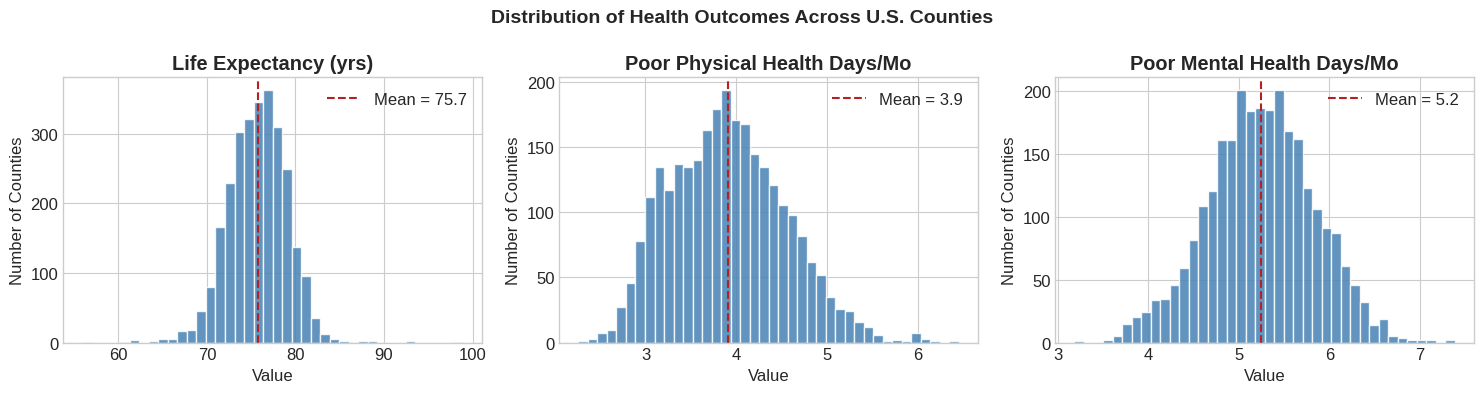

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, name) in zip(axes, OUTCOME_NAMES.items()):
    ax.hist(df[col], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color="firebrick", linestyle="--", linewidth=1.5,
               label=f"Mean = {df[col].mean():.1f}")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Number of Counties")
    ax.legend()

fig.suptitle("Distribution of Health Outcomes Across U.S. Counties", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(VIS_DIR / "outcome_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

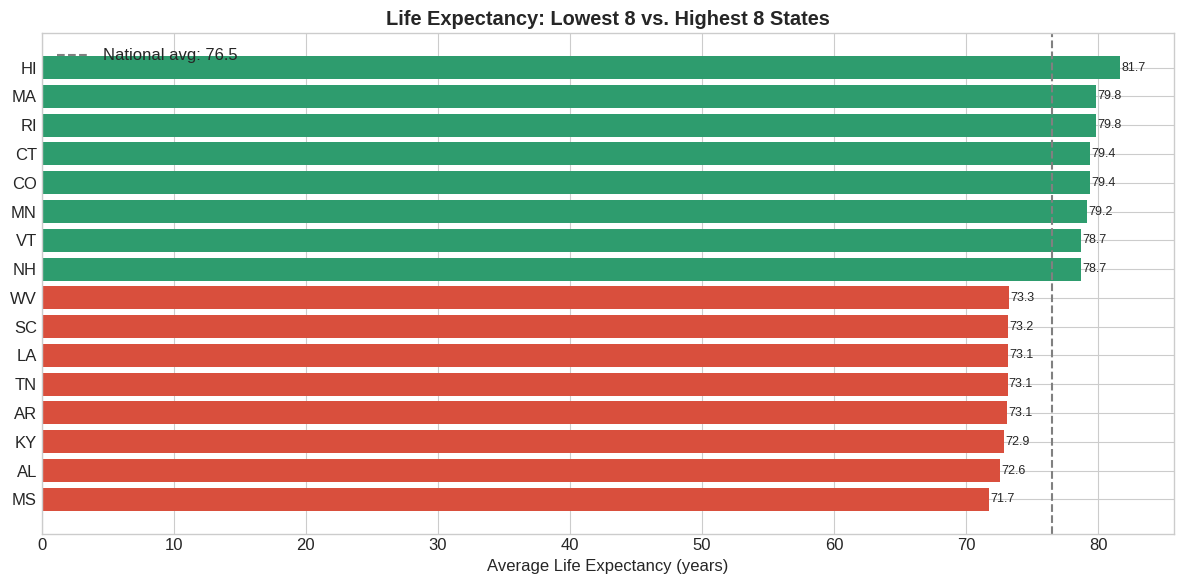

In [10]:
state_avg = df.groupby("state")["v147_rawvalue"].mean().sort_values()
bottom8, top8 = state_avg.head(8), state_avg.tail(8)
display_data = pd.concat([bottom8, top8])
colors = ["#D94F3D"] * 8 + ["#2E9C6E"] * 8

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(display_data.index, display_data.values, color=colors)
ax.axvline(state_avg.mean(), color="gray", linestyle="--", label=f"National avg: {state_avg.mean():.1f}")
ax.set_xlabel("Average Life Expectancy (years)")
ax.set_title("Life Expectancy: Lowest 8 vs. Highest 8 States", fontweight="bold")
ax.legend()

for bar, val in zip(bars, display_data.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2, f"{val:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(VIS_DIR / "state_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Correlation Analysis

Pearson correlation (`r`) measures the strength and direction of the linear relationship between each predictor and
each outcome: `|r| > 0.70` is considered strong, `0.40–0.70` moderate, and `< 0.40` weak.

In [11]:
predictor_cols = list(PREDICTOR_VARS.keys())

corr_df = pd.DataFrame(index=predictor_cols)
for col, name in OUTCOME_NAMES.items():
    corr_df[name] = [df[col].corr(df[pred]) for pred in predictor_cols]

corr_df.index = [PREDICTOR_VARS[k] for k in predictor_cols]
corr_df = corr_df.round(3)
corr_df.sort_values("Life Expectancy (yrs)")

,Life Expectancy (yrs),Poor Physical Health Days/Mo,Poor Mental Health Days/Mo
Adult Smoking %,-0.750,0.821,0.657
Children in Poverty %,-0.746,0.761,0.582
Physical Inactivity %,-0.745,0.804,0.563
Diabetes Prevalence %,-0.736,0.764,0.557
Food Insecurity %,-0.722,0.789,0.669
Insufficient Sleep %,-0.662,0.729,0.654
Adult Obesity %,-0.649,0.582,0.371
Single-Parent HH %,-0.566,0.469,0.374
Income Inequality (ratio),-0.437,0.450,0.387
Uninsured %,-0.332,0.365,0.201


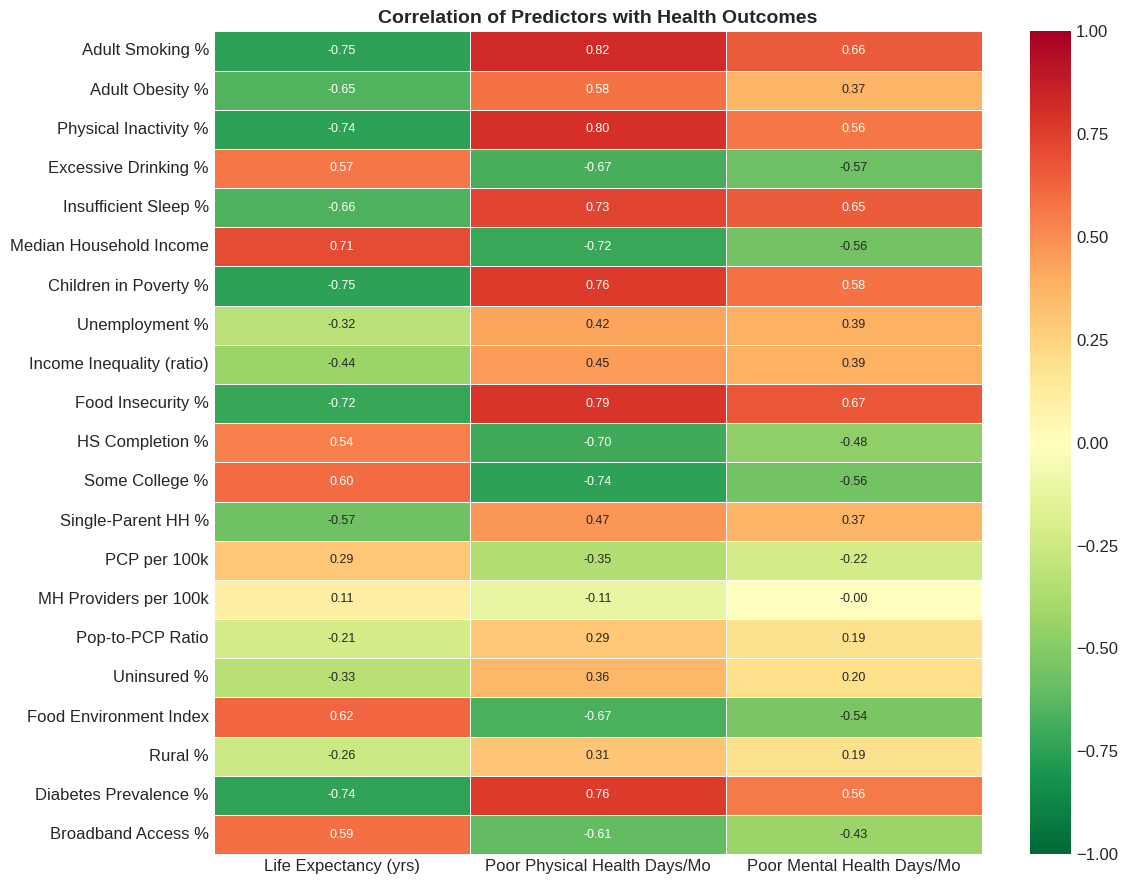

In [12]:
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_df, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={"size": 9},
)
ax.set_title("Correlation of Predictors with Health Outcomes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(VIS_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

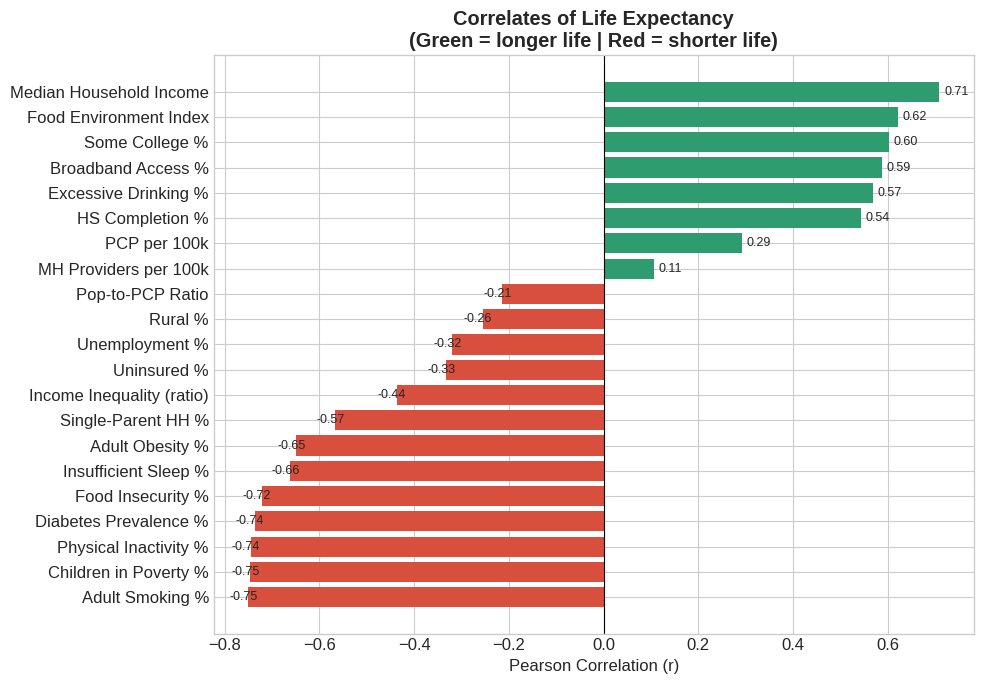

In [13]:
le_corr = corr_df["Life Expectancy (yrs)"].sort_values()
colors = ["#D94F3D" if v < 0 else "#2E9C6E" for v in le_corr.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(le_corr.index, le_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation (r)")
ax.set_title("Correlates of Life Expectancy\n(Green = longer life | Red = shorter life)", fontweight="bold")
for bar, val in zip(bars, le_corr.values):
    x_pos = val - 0.04 if val < 0 else val + 0.01
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(VIS_DIR / "le_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

The strongest negative correlates with life expectancy (`r < -0.60`) are adult smoking, physical inactivity,
poverty, and food insecurity — counties where residents smoke more, exercise less, and earn less consistently show
shorter lifespans, even before controlling for other factors.

## 6. Linear Regression — Life Expectancy

A multivariate linear regression estimates each predictor's association with life expectancy while holding the
others constant, and reports R² — the share of county-to-county variation in life expectancy the model explains.

In [14]:
reg_features = [
    "v009_rawvalue", "v070_rawvalue", "v060_rawvalue", "v024_rawvalue", "v063_rawvalue",
    "v085_rawvalue", "v004_rawvalue", "v069_rawvalue", "v139_rawvalue", "v143_rawvalue",
]
reg_feature_names = [PREDICTOR_VARS[f] for f in reg_features]

X_reg = df[reg_features].values
y_reg = df["v147_rawvalue"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

lr_model = LinearRegression().fit(X_train, y_train)

r2_train = r2_score(y_train, lr_model.predict(X_train))
r2_test = r2_score(y_test, lr_model.predict(X_test))
rmse = np.sqrt(mean_squared_error(y_test, lr_model.predict(X_test)))

print(f"Training counties: {len(X_train):,}  |  Test counties: {len(X_test):,}")
print(f"R² (train): {r2_train:.3f}")
print(f"R² (test):  {r2_test:.3f}")
print(f"RMSE (test): {rmse:.2f} years")

Training counties: 2,207  |  Test counties: 552
R² (train): 0.693
R² (test):  0.736
RMSE (test): 1.68 years


In [15]:
coeff_df = (
    pd.DataFrame({"Variable": reg_feature_names, "Coefficient": lr_model.coef_})
    .sort_values("Coefficient")
    .reset_index(drop=True)
)
coeff_df

,Variable,Coefficient
0,Diabetes Prevalence %,-34.055109
1,Adult Smoking %,-26.104986
2,Food Insecurity %,-15.338248
3,Insufficient Sleep %,-14.898847
4,Children in Poverty %,-1.831368
5,Some College %,-1.714028
6,Uninsured %,-0.944303
7,Median Household Income,0.000029
8,Physical Inactivity %,2.755290
9,PCP per 100k,248.499403


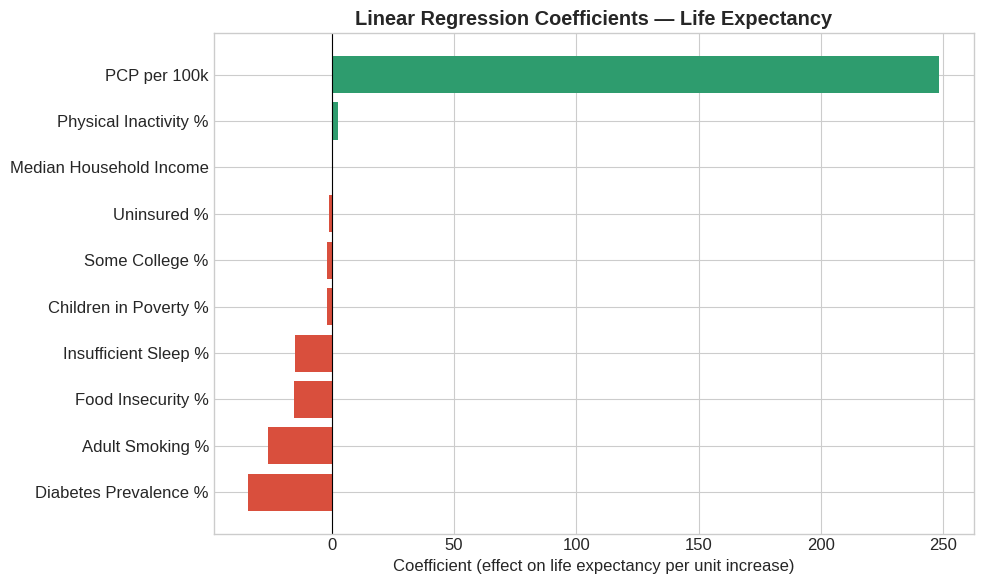

In [16]:
colors = ["#D94F3D" if c < 0 else "#2E9C6E" for c in coeff_df["Coefficient"]]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coeff_df["Variable"], coeff_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (effect on life expectancy per unit increase)")
ax.set_title("Linear Regression Coefficients — Life Expectancy", fontweight="bold")
plt.tight_layout()
plt.savefig(VIS_DIR / "regression_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

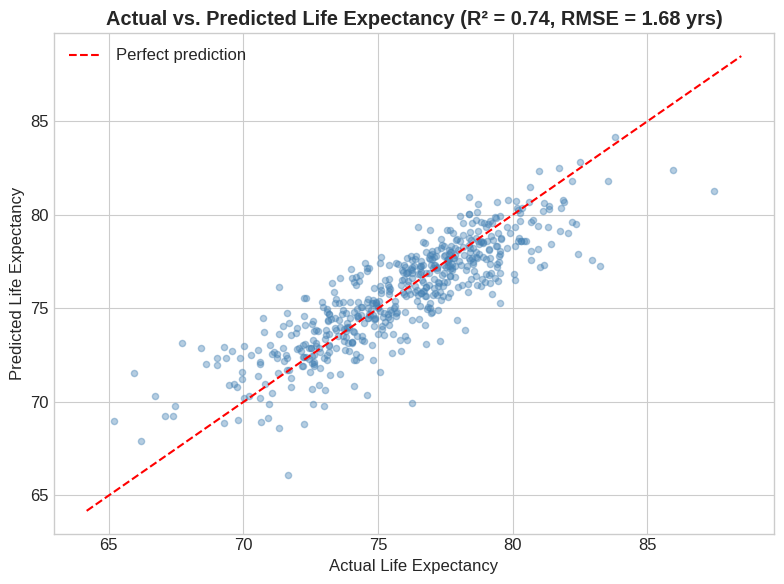

In [17]:
y_pred_test = lr_model.predict(X_test)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_test, alpha=0.4, color="steelblue", s=20)
lims = [min(y_test.min(), y_pred_test.min()) - 1, max(y_test.max(), y_pred_test.max()) + 1]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Life Expectancy")
ax.set_ylabel("Predicted Life Expectancy")
ax.set_title(f"Actual vs. Predicted Life Expectancy (R² = {r2_test:.2f}, RMSE = {rmse:.2f} yrs)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / "actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Random Forest — Physical & Mental Health Burden

Random forest regression captures non-linear effects and interactions (e.g. smoking compounding with poverty) that
linear regression cannot. Performance is validated with 5-fold cross-validation, which is more robust than a single
train/test split.

In [18]:
rf_features = [
    "v009_rawvalue", "v011_rawvalue", "v070_rawvalue", "v049_rawvalue", "v085_rawvalue",
    "v004_rawvalue", "v062_rawvalue", "v023_rawvalue", "v024_rawvalue", "v044_rawvalue",
    "v063_rawvalue", "v168_rawvalue", "v069_rawvalue", "v082_rawvalue", "v133_rawvalue",
    "v139_rawvalue", "v058_rawvalue", "v166_rawvalue", "v060_rawvalue", "v143_rawvalue",
]
rf_feature_names = [PREDICTOR_VARS[f] for f in rf_features]

X_rf = df[rf_features].values
y_rf = df["v036_rawvalue"].values  # Poor Physical Health Days

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=RANDOM_STATE
)

rf_model = RandomForestRegressor(
    n_estimators=200, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_rf, y_train_rf)

cv_scores = cross_val_score(rf_model, X_rf, y_rf, cv=5, scoring="r2")
y_pred_rf = rf_model.predict(X_test_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))

print(f"5-fold CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Test R²:      {r2_rf:.3f}")
print(f"Test RMSE:    {rmse_rf:.3f} days/month")

5-fold CV R²: 0.811 ± 0.034
Test R²:      0.892
Test RMSE:    0.209 days/month


In [19]:
importance_df = (
    pd.DataFrame({
        "Variable": rf_feature_names,
        "Importance (%)": rf_model.feature_importances_ * 100,
    })
    .sort_values("Importance (%)", ascending=False)
    .reset_index(drop=True)
)
importance_df.round(1)

,Variable,Importance (%)
0,Adult Smoking %,35.7
1,Physical Inactivity %,30.1
2,Diabetes Prevalence %,11.4
3,Some College %,5.4
4,Food Insecurity %,3.8
5,Excessive Drinking %,3.6
6,Insufficient Sleep %,2.1
7,Unemployment %,1.4
8,Uninsured %,1.0
9,Median Household Income,0.9


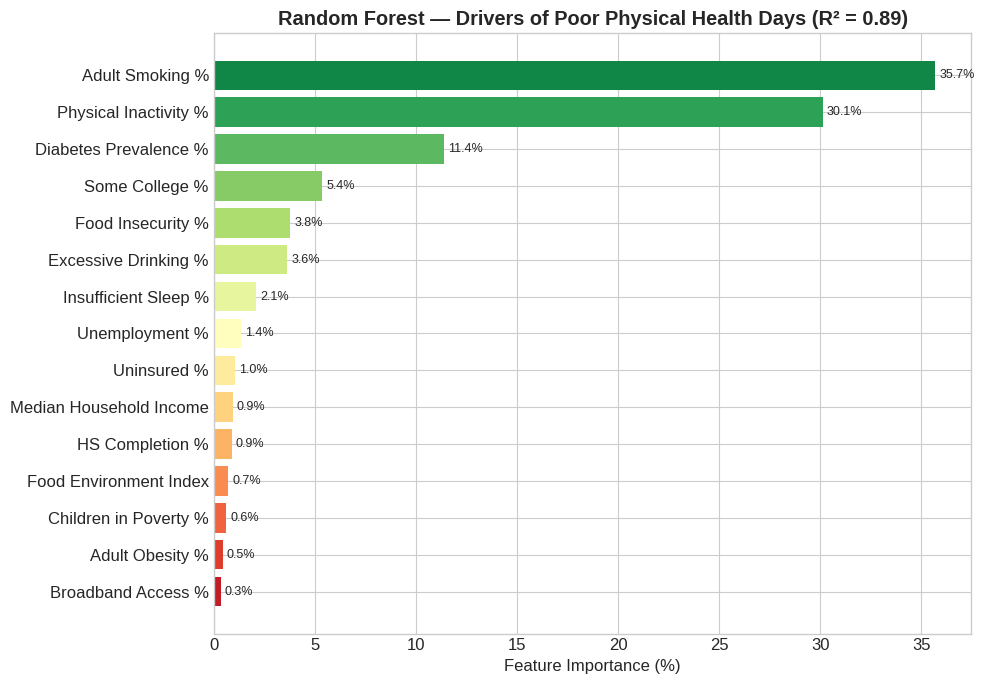

In [20]:
top15 = importance_df.head(15)
colors = sns.color_palette("RdYlGn_r", len(top15))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15["Variable"][::-1], top15["Importance (%)"][::-1], color=colors[::-1])
ax.set_xlabel("Feature Importance (%)")
ax.set_title(f"Random Forest — Drivers of Poor Physical Health Days (R² = {r2_rf:.2f})", fontweight="bold")
for bar, val in zip(bars, top15["Importance (%)"][::-1].values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(VIS_DIR / "rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# Repeat the model for mental health burden
y_mh = df["v042_rawvalue"].values
X_train_mh, X_test_mh, y_train_mh, y_test_mh = train_test_split(
    X_rf, y_mh, test_size=0.2, random_state=RANDOM_STATE
)
rf_mh = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1)
rf_mh.fit(X_train_mh, y_train_mh)
cv_mh = cross_val_score(rf_mh, X_rf, y_mh, cv=5, scoring="r2")

imp_mh = (
    pd.DataFrame({"Variable": rf_feature_names, "Importance (%)": rf_mh.feature_importances_ * 100})
    .sort_values("Importance (%)", ascending=False)
    .reset_index(drop=True)
)

print(f"Mental Health Days — 5-fold CV R²: {cv_mh.mean():.3f} ± {cv_mh.std():.3f}")
imp_mh.head(5).round(1)

Mental Health Days — 5-fold CV R²: 0.567 ± 0.140


,Variable,Importance (%)
0,Adult Smoking %,44.0
1,Food Insecurity %,14.2
2,Insufficient Sleep %,8.7
3,Excessive Drinking %,5.6
4,Unemployment %,5.1


## 8. Healthcare Access — Does It Matter Beyond Income?

Counties with more money tend to have better health outcomes, which raises an obvious question: is healthcare
access simply a proxy for income, or does it have an independent effect? This is tested three ways: a simple
group comparison, a within-income-quintile comparison, and nested regression models.

In [22]:
pcp_median = df["v004_rawvalue"].median()
df["pcp_access"] = np.where(df["v004_rawvalue"] >= pcp_median, "High PCP Access", "Low PCP Access")

group_comparison = df.groupby("pcp_access")[OUTCOMES].mean().round(2)
group_comparison.columns = list(OUTCOME_NAMES.values())

le_gap = (
    df.loc[df["pcp_access"] == "High PCP Access", "v147_rawvalue"].mean()
    - df.loc[df["pcp_access"] == "Low PCP Access", "v147_rawvalue"].mean()
)
print(f"Life expectancy gap (High vs. Low PCP access): {le_gap:.1f} years")
group_comparison

Life expectancy gap (High vs. Low PCP access): 1.8 years


,Life Expectancy (yrs),Poor Physical Health Days/Mo,Poor Mental Health Days/Mo
pcp_access,,,
High PCP Access,76.62,3.70,5.12
Low PCP Access,74.84,4.11,5.37


In [23]:
# Within-income-quintile comparison: does the access gap persist once income is held constant?
df["income_quintile"] = pd.qcut(
    df["v063_rawvalue"], 5, labels=["Q1 (Lowest Income)", "Q2", "Q3", "Q4", "Q5 (Highest Income)"]
)

controlled = df.groupby(["income_quintile", "pcp_access"])["v036_rawvalue"].mean().unstack()
controlled.columns = ["High PCP Access", "Low PCP Access"]
controlled["Gap (Low - High)"] = (controlled["Low PCP Access"] - controlled["High PCP Access"]).round(3)
controlled.round(3)

,High PCP Access,Low PCP Access,Gap (Low - High)
income_quintile,,,
Q1 (Lowest Income),4.546,4.695,0.149
Q2,4.017,4.229,0.212
Q3,3.746,3.981,0.235
Q4,3.492,3.670,0.178
Q5 (Highest Income),3.228,3.473,0.245


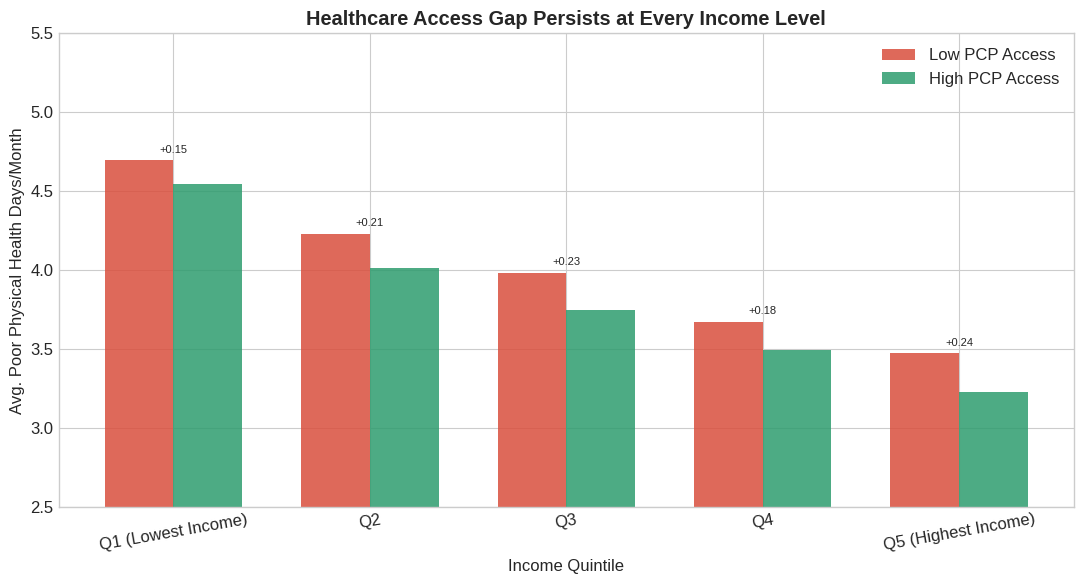

In [24]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(controlled.index))
width = 0.35

ax.bar(x - width / 2, controlled["Low PCP Access"], width, label="Low PCP Access", color="#D94F3D", alpha=0.85)
ax.bar(x + width / 2, controlled["High PCP Access"], width, label="High PCP Access", color="#2E9C6E", alpha=0.85)

ax.set_xlabel("Income Quintile")
ax.set_ylabel("Avg. Poor Physical Health Days/Month")
ax.set_title("Healthcare Access Gap Persists at Every Income Level", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(controlled.index, rotation=10)
ax.legend()
ax.set_ylim(2.5, 5.5)

for xi, (_, row) in zip(x, controlled.iterrows()):
    ax.annotate(f"+{row['Gap (Low - High)']:.2f}", xy=(xi, row["Low PCP Access"] + 0.05),
                ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(VIS_DIR / "access_by_income.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Nested regression: does adding access variables improve an income-only model?
m1 = LinearRegression().fit(df[["v063_rawvalue"]].values, df["v036_rawvalue"].values)
r2_income_only = r2_score(df["v036_rawvalue"].values, m1.predict(df[["v063_rawvalue"]].values))

m2 = LinearRegression().fit(df[["v063_rawvalue", "v004_rawvalue"]].values, df["v036_rawvalue"].values)
r2_income_access = r2_score(df["v036_rawvalue"].values, m2.predict(df[["v063_rawvalue", "v004_rawvalue"]].values))

m3 = LinearRegression().fit(df[["v063_rawvalue", "v085_rawvalue"]].values, df["v036_rawvalue"].values)
r2_income_uninsured = r2_score(df["v036_rawvalue"].values, m3.predict(df[["v063_rawvalue", "v085_rawvalue"]].values))

nested_models = pd.DataFrame({
    "Model": ["Income only", "Income + PCP Access", "Income + Uninsured Rate"],
    "R2": [r2_income_only, r2_income_access, r2_income_uninsured],
})
nested_models["R2 Gain vs. Income Only"] = nested_models["R2"] - r2_income_only
print(f"PCP coefficient in Model 2: {m2.coef_[1]:.4f} "
      "(negative = more PCPs per capita associated with fewer poor-health days)")
nested_models.round(4)

PCP coefficient in Model 2: -298.7767 (negative = more PCPs per capita associated with fewer poor-health days)


,Model,R2,R2 Gain vs. Income Only
0,Income only,0.5147,0.0000
1,Income + PCP Access,0.5406,0.0259
2,Income + Uninsured Rate,0.5324,0.0177


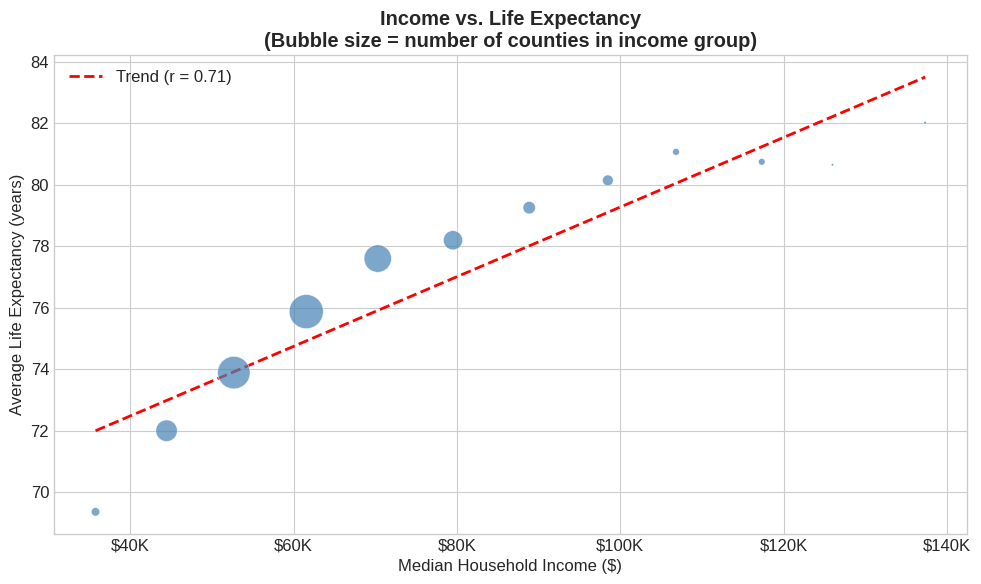

Income accounts for 50% of life expectancy variance; the remaining 50% reflects behavioral, access, and other factors.


In [26]:
income_bins = pd.cut(df["v063_rawvalue"], bins=12)
scatter_data = df.groupby(income_bins).agg(
    income=("v063_rawvalue", "median"), le=("v147_rawvalue", "mean"), n=("v147_rawvalue", "count")
).dropna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(scatter_data["income"], scatter_data["le"], s=scatter_data["n"] * 0.8, alpha=0.7,
           color="steelblue", edgecolors="white", linewidths=0.5, zorder=3)

z = np.polyfit(scatter_data["income"], scatter_data["le"], 1)
x_line = np.linspace(scatter_data["income"].min(), scatter_data["income"].max(), 100)
r_income_le = df["v063_rawvalue"].corr(df["v147_rawvalue"])
ax.plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=2, label=f"Trend (r = {r_income_le:.2f})")

ax.set_xlabel("Median Household Income ($)")
ax.set_ylabel("Average Life Expectancy (years)")
ax.set_title("Income vs. Life Expectancy\n(Bubble size = number of counties in income group)", fontweight="bold")
ax.legend()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
plt.tight_layout()
plt.savefig(VIS_DIR / "income_vs_le.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Income accounts for {r_income_le**2 * 100:.0f}% of life expectancy variance; "
      f"the remaining {100 - r_income_le**2 * 100:.0f}% reflects behavioral, access, and other factors.")

## 9. County Segmentation (K-Means Clustering)

Clustering groups counties with similar health, socioeconomic, and access profiles, producing distinct
"archetypes" that can inform a targeted market-entry strategy.

In [27]:
cluster_features = [
    "v009_rawvalue", "v070_rawvalue", "v060_rawvalue", "v024_rawvalue", "v023_rawvalue",
    "v063_rawvalue", "v139_rawvalue", "v168_rawvalue", "v004_rawvalue", "v062_rawvalue", "v058_rawvalue",
]
cluster_feature_names = [PREDICTOR_VARS[f] for f in cluster_features]

X_cluster = df[cluster_features].values
X_scaled = StandardScaler().fit_transform(X_cluster)

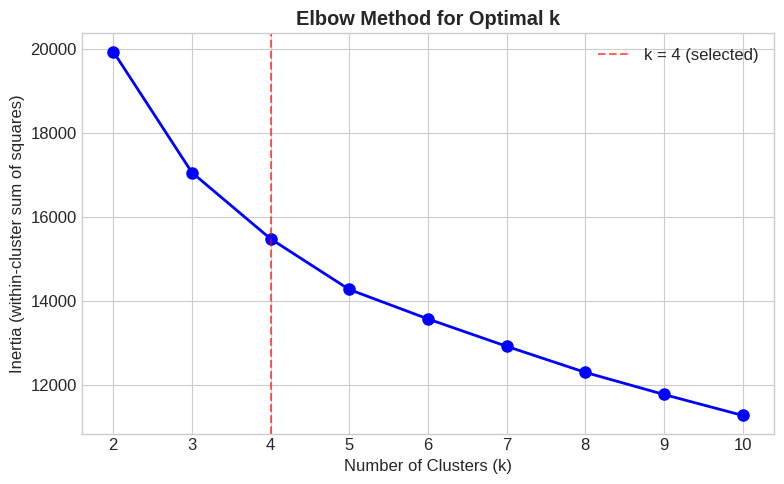

In [28]:
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, "bo-", markersize=8, linewidth=2)
ax.axvline(4, color="red", linestyle="--", alpha=0.6, label="k = 4 (selected)")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.set_title("Elbow Method for Optimal k", fontweight="bold")
ax.set_xticks(list(k_range))
ax.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / "elbow_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
N_CLUSTERS = 4
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)

df["cluster"].value_counts().sort_index().rename("counties")

cluster
0    526
1    559
2    955
3    719
Name: counties, dtype: int64

In [30]:
cluster_profile = df.groupby("cluster")[OUTCOMES + cluster_features].mean()
cluster_profile.index.name = "Cluster"

col_rename = {**{o: OUTCOME_NAMES[o] for o in OUTCOMES},
              **{f: PREDICTOR_VARS[f] for f in cluster_features}}
cluster_profile_named = cluster_profile.rename(columns=col_rename).round(2)
cluster_profile_named

,Life Expectancy (yrs),Poor Physical Health Days/Mo,Poor Mental Health Days/Mo,Adult Smoking %,Physical Inactivity %,Diabetes Prevalence %,Children in Poverty %,Unemployment %,Median Household Income,Food Insecurity %,HS Completion %,PCP per 100k,MH Providers per 100k,Rural %
Cluster,,,,,,,,,,,,,,
0,79.06,3.28,4.85,0.14,0.21,0.09,0.12,0.03,82975.37,0.09,0.93,0.0,0.0,0.25
1,72.05,4.72,5.81,0.24,0.34,0.13,0.31,0.04,46763.34,0.16,0.82,0.0,0.0,0.81
2,74.72,4.08,5.43,0.20,0.28,0.11,0.21,0.04,58069.61,0.13,0.88,0.0,0.0,0.56
3,77.48,3.50,4.86,0.18,0.24,0.09,0.14,0.03,69404.93,0.09,0.92,0.0,0.0,0.75


In [31]:
top_states_by_cluster = {
    c: df.loc[df["cluster"] == c, "state"].value_counts().head(5).index.tolist()
    for c in range(N_CLUSTERS)
}
for c, states in top_states_by_cluster.items():
    print(f"Cluster {c} — top states: {', '.join(states)}")

Cluster 0 — top states: CO, VA, CA, MN, WA
Cluster 1 — top states: TX, GA, MS, KY, AR
Cluster 2 — top states: TX, MI, NC, IL, IN
Cluster 3 — top states: IA, MN, WI, NE, KS


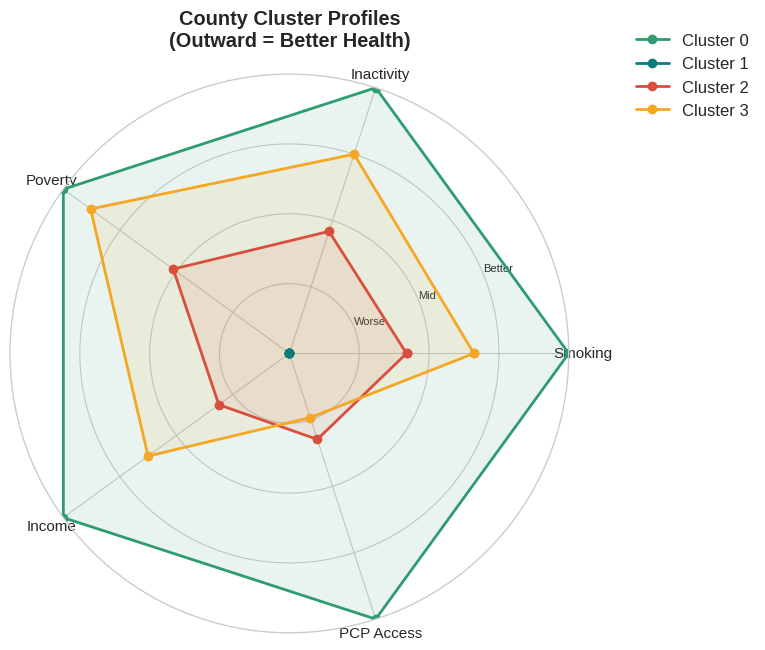

In [32]:
radar_vars = ["v009_rawvalue", "v070_rawvalue", "v024_rawvalue", "v063_rawvalue", "v004_rawvalue"]
radar_names = ["Smoking", "Inactivity", "Poverty", "Income", "PCP Access"]

radar_data = cluster_profile[radar_vars].copy()
for col in radar_vars:
    col_min, col_max = radar_data[col].min(), radar_data[col].max()
    radar_data[col] = (radar_data[col] - col_min) / (col_max - col_min + 1e-9)

# Invert "bad when high" variables so that outward always means healthier
for col in ["v009_rawvalue", "v070_rawvalue", "v024_rawvalue"]:
    radar_data[col] = 1 - radar_data[col]

angles = [n / float(len(radar_vars)) * 2 * np.pi for n in range(len(radar_vars))]
angles += angles[:1]

cluster_colors = ["#2E9C6E", "#0A7C7C", "#D94F3D", "#F5A623"]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for c in range(N_CLUSTERS):
    values = radar_data.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, color=cluster_colors[c], label=f"Cluster {c}")
    ax.fill(angles, values, alpha=0.1, color=cluster_colors[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_names, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(["Worse", "Mid", "Better"], fontsize=8)
ax.set_title("County Cluster Profiles\n(Outward = Better Health)", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig(VIS_DIR / "cluster_radar.png", dpi=150, bbox_inches="tight")
plt.show()

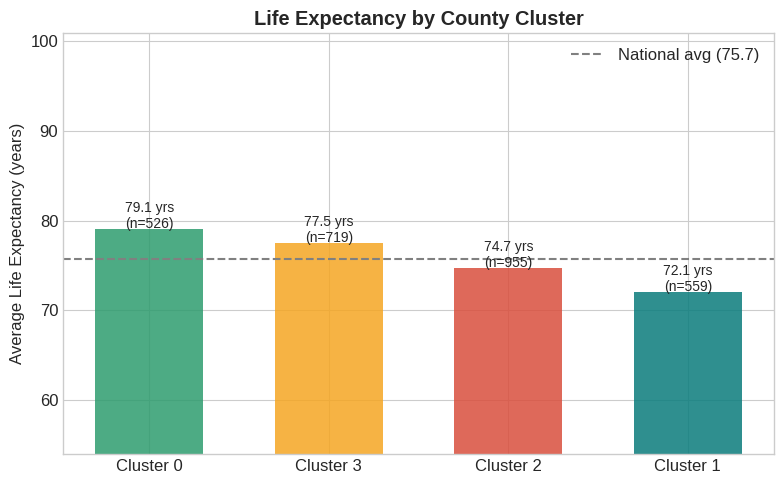

In [33]:
le_by_cluster = df.groupby("cluster")["v147_rawvalue"].mean().sort_values(ascending=False)
cluster_n = df["cluster"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
for i, (c, le) in enumerate(le_by_cluster.items()):
    ax.bar(i, le, color=cluster_colors[c], alpha=0.85, width=0.6)
    ax.text(i, le + 0.1, f"{le:.1f} yrs\n(n={cluster_n[c]})", ha="center", fontsize=10)

ax.set_xticks(range(N_CLUSTERS))
ax.set_xticklabels([f"Cluster {c}" for c in le_by_cluster.index])
ax.set_ylabel("Average Life Expectancy (years)")
ax.set_title("Life Expectancy by County Cluster", fontweight="bold")
ax.set_ylim(df["v147_rawvalue"].min() - 2, df["v147_rawvalue"].max() + 2)
ax.axhline(df["v147_rawvalue"].mean(), color="gray", linestyle="--",
           label=f"National avg ({df['v147_rawvalue'].mean():.1f})")
ax.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / "cluster_le.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
SOUTHERN_STATES = {"AL", "AR", "FL", "GA", "KY", "LA", "MS", "NC", "OK", "SC", "TN", "TX", "VA", "WV"}

geo_summary = []
for c in range(N_CLUSTERS):
    cluster_df = df[df["cluster"] == c]
    geo_summary.append({
        "Cluster": c,
        "Counties": len(cluster_df),
        "Life Expectancy": round(cluster_df["v147_rawvalue"].mean(), 1),
        "% in Southern States": round(cluster_df["state"].isin(SOUTHERN_STATES).mean() * 100, 1),
    })

pd.DataFrame(geo_summary)

,Cluster,Counties,Life Expectancy,% in Southern States
0,0,526,79.1,21.3
1,1,559,72.1,86.8
2,2,955,74.7,51.2
3,3,719,77.5,20.6


## 10. Telehealth Opportunity Analysis

The clustering results point to a high-burden, access-poor archetype concentrated in the South. This section
translates that pattern into an explicit, reproducible county screen for telehealth market prioritization, using
the same variables and thresholds already established earlier in the notebook:

- **Rural:** `Rural %` (`v058_rawvalue`) at or above 50% (majority-rural counties)
- **Low physician access:** below-median primary care physicians per 100k (the `pcp_access` split from Section 8)
- **Low mental health provider access:** below-median mental health providers per 100k
- **High physical health burden:** above-median poor physical health days/month
- **High mental health burden:** above-median poor mental health days/month

A county qualifies as a physical-health opportunity if it is rural, low-PCP-access, and high-physical-burden; as a
mental-health opportunity if it is rural, low-MH-provider-access, and high-mental-burden. The combined opportunity
set is the union of both groups.

In [35]:
mh_median = df["v062_rawvalue"].median()
physical_median = df["v036_rawvalue"].median()
mental_median = df["v042_rawvalue"].median()

is_rural = df["v058_rawvalue"] >= 0.5
is_low_pcp = df["pcp_access"] == "Low PCP Access"
is_low_mh = df["v062_rawvalue"] < mh_median
is_high_physical = df["v036_rawvalue"] > physical_median
is_high_mental = df["v042_rawvalue"] > mental_median

physical_opportunity = is_rural & is_low_pcp & is_high_physical
mental_opportunity = is_rural & is_low_mh & is_high_mental
combined_opportunity = physical_opportunity | mental_opportunity

n_physical = int(physical_opportunity.sum())
n_mental = int(mental_opportunity.sum())
n_combined = int(combined_opportunity.sum())
pct_south_combined = df.loc[combined_opportunity, "state"].isin(SOUTHERN_STATES).mean() * 100

opportunity_summary = pd.DataFrame({
    "Segment": [
        "Rural + Low PCP Access + High Physical Burden",
        "Rural + Low MH Provider Access + High Mental Burden",
        "Combined Opportunity Set (union, deduplicated)",
    ],
    "Counties": [n_physical, n_mental, n_combined],
})
print(f"Combined opportunity set: {n_combined} counties, "
      f"{pct_south_combined:.0f}% located in Southern states")
opportunity_summary

Combined opportunity set: 891 counties, 71% located in Southern states


,Segment,Counties
0,Rural + Low PCP Access + High Physical Burden,732
1,Rural + Low MH Provider Access + High Mental B...,630
2,"Combined Opportunity Set (union, deduplicated)",891


## 11. Key Findings

**Health inequality is large and structured, not random.** Life expectancy among the 2,759 counties with complete
data for this analysis spans roughly 56 to 99 years. State-level averages range from 71.7 years (Mississippi) to
81.7 years (Hawaii) — a gap of roughly 10 years — associated with identifiable behavioral and socioeconomic
factors rather than random variation.

**Behavioral factors dominate physical and mental health burden.** The random forest model explains 81% of the
variation in poor physical health days (5-fold CV R² = 0.811), with adult smoking (35.7% of feature importance)
and physical inactivity (30.1%) as the leading drivers — together accounting for nearly two-thirds (65.8%) of the
model's explanatory power. Mental health burden is explained less completely (5-fold CV R² = 0.567), led by
smoking (44.0%), food insecurity (14.2%), and insufficient sleep (8.7%).

**Income is a strong predictor of life expectancy, but not the whole story.** Income correlates with life
expectancy at r = 0.71 and accounts for roughly 50% of the variance across counties; counties with similar income
levels still show substantial variation, pointing to access and behavior as additional levers.

**Healthcare access has an effect independent of income.** Counties with above-median primary care physician
(PCP) supply show 1.8 more years of life expectancy on average, and this gap persists across every income
quintile. Adding PCP access to an income-only regression improves R² from 0.515 to 0.541 (a gain of roughly 2.6
percentage points); adding the uninsured rate adds a further 1.8 points — evidence that access is not simply a
proxy for wealth.

**Four distinct county archetypes emerge from clustering**, ranging from a high-income, lower-risk archetype
(Cluster 0: 79.1-year average life expectancy) to a high-burden archetype (Cluster 1: 72.1-year average life
expectancy, elevated smoking and inactivity, higher poverty, and 86.8% concentration in Southern states).

## 12. Strategic Recommendations

**Recommendation for GetBetterHealth.com:** applying the opportunity screen defined in Section 10 — rural counties
with below-median physician or mental-health-provider access and above-median health burden — identifies 732
counties as physical-health opportunities and 630 as mental-health opportunities, for a combined, deduplicated set
of 891 counties. Roughly 71% of this combined opportunity set is concentrated in Southern states, consistent with
the geographic pattern of the highest-burden cluster identified in Section 9. These counties combine elevated
health need with limited existing access to in-person care, making them a reasonable starting point for
prioritizing a telehealth expansion strategy — with the specific county list fully reproducible from this
notebook. As a secondary priority, the high-income, low-risk archetype (Cluster 0) represents lower acquisition
urgency but may still offer opportunity for preventive or convenience-oriented telehealth offerings.

## 13. Limitations

- **Observational, cross-sectional data.** All relationships reported here are statistical associations, not
  causal effects. The models do not control for every possible confounder, and reverse causality (for example,
  poor health limiting workforce participation and household income) cannot be ruled out.
- **County-level aggregation.** Findings describe average patterns across counties and should not be used to
  predict outcomes for individual residents.
- **Variable coverage and data quality.** The analysis uses a curated subset of 21 predictors out of the 88
  variables available in the source dataset, and roughly 12% of counties (384 of 3,143) were dropped due to
  missing values in one or more analysis variables. Measurement error or reporting inconsistencies in the
  underlying county-level estimates are possible.
- **Model performance in context.** The random forest models leave meaningful unexplained variance — particularly
  for mental health burden (5-fold CV R² = 0.567) — indicating that mental health outcomes are likely influenced
  by factors outside this dataset.
- **Opportunity screen thresholds.** The Section 10 telehealth opportunity segmentation uses median-based cutoffs
  for rurality, access, and health burden. These are transparent, reasonable defaults rather than the only valid
  definition; different thresholds would shift the specific county counts.

## 14. Conclusion

This analysis finds that county-level health outcomes are shaped by an interacting set of behavioral,
socioeconomic, and healthcare-access factors: behavior (smoking, physical inactivity) is the single largest driver
of physical health burden, income is a strong but incomplete predictor of life expectancy, and healthcare access
has an effect independent of income. Segmenting counties into distinct archetypes, and screening for rural,
access-poor, high-burden counties, produces a reproducible, data-driven shortlist for GetBetterHealth.com's
telehealth expansion strategy. As with any observational analysis, these findings should inform prioritization and
further due diligence rather than substitute for it.

**Data source:** [County Health Rankings & Roadmaps, 2024](https://www.countyhealthrankings.org/health-data). This
notebook is shared for portfolio and educational purposes.